In [37]:
import os
import zipfile
from pathlib import Path
import shutil
import xarray as xr
import matplotlib.pyplot as plt

In [38]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]
print(f"Current working directory: {base_path}")
print(f"Repository root directory: {repo_root}")

Current working directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\Duomenu_mokslo_projektas\code\python\datasets_prep
Repository root directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT


In [ ]:
SOURCE_DIR = os.path.join(repo_root, "CAMS_Downloads", "peroxyacyl_nitrates")
TARGET_DIR = os.path.join(repo_root, "CAMS unzip", "peroxyacyl_nitrates")

os.makedirs(TARGET_DIR, exist_ok=True)

for file_name in os.listdir(SOURCE_DIR):
    if file_name.endswith(".zip"):
        zip_path = os.path.join(SOURCE_DIR, file_name)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            internal_files = zip_ref.namelist()
            
            nc_files = [f for f in internal_files if f.endswith('.nc')]
            
            for nc_file in nc_files:
                target_file_name = file_name.replace(".zip", ".nc")
                
                source = zip_ref.open(nc_file)
                target_path = os.path.join(TARGET_DIR, target_file_name)
                
                with open(target_path, "wb") as target:
                    shutil.copyfileobj(source, target)
                
                print(f"Extracted and flattened: {target_file_name}")

print("\nDone! All .nc files are now in:", TARGET_DIR)

Extracted and flattened: cams_2018_01_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_02_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_03_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_04_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_05_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_06_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_07_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_08_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_09_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_10_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_11_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2018_12_particulate_matter_25um_validated.nc
Extracted and flattened: cams_2019_01_particulate_matter_25um_validated.nc
Extracted and flattened: 

In [8]:
file_path = r"C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\CAMS unzip\dust\cams_2018_07_dust_validated.nc"

ds = xr.open_dataset(file_path)
print(ds)

<xarray.Dataset> Size: 113kB
Dimensions:  (time: 744, lat: 6, lon: 6)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2018-07-01 ... 2018-07-31T23:00:00
  * lat      (lat) float64 48B 54.4 54.5 54.6 54.7 54.8 54.9
  * lon      (lon) float64 48B 25.0 25.1 25.2 25.3 25.4 25.5
Data variables:
    dust     (time, lat, lon) float32 107kB ...
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality validated reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service


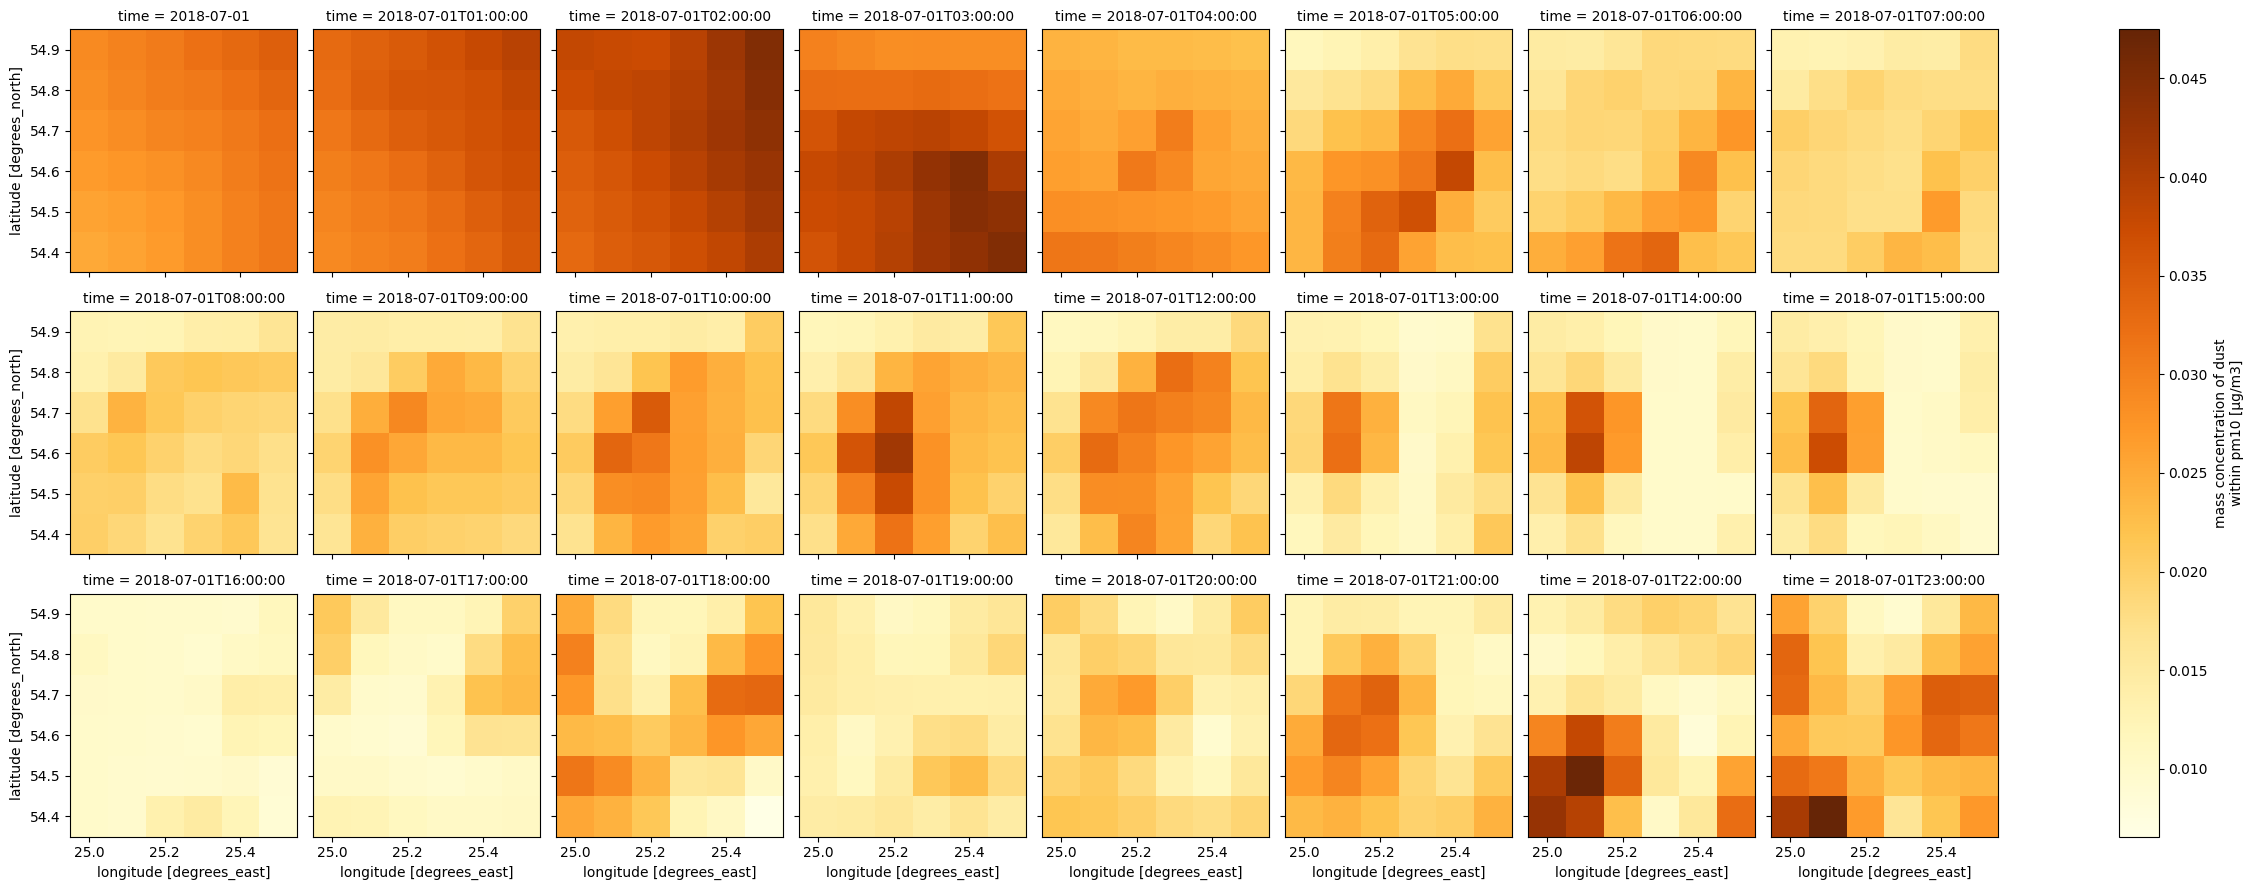

In [10]:
plot = ds.dust.isel(time=slice(0, 24)).plot(
    col="time", 
    col_wrap=8, 
    cmap="YlOrBr"
)

plt.show()

```{python}
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor

CSV_OUTPUT = r'sentinel_data\lithuania_methane_vilnius.csv'
FOLDER_TO_PROCESS = "S5P_Methane"

base_path = Path(os.getcwd())
FOLDER = os.path.join(base_path, 'sentinel_data', FOLDER_TO_PROCESS)
nc_files = [f for f in os.listdir(FOLDER) if f.endswith('.nc')]

def prepare_dataset(file_path):
    vilnius_lon, vilnius_lat = 25.2797, 54.6872
    full_path = os.path.join(FOLDER, file_path)
    
    try:
        with xr.open_dataset(full_path) as ds:
            
            print(f"[{file_path}]: boxing.")
            ds_box = ds.sel(
                lon=slice(vilnius_lon - 0.25, vilnius_lon + 0.25),
                lat=slice(vilnius_lat - 0.25, vilnius_lat + 0.25))

            # print(f"[{file_path}]: grouping.")
            #ds_box = ds_box.groupby('time').mean()
            ds_regional = ds_box.mean(dim=['lat', 'lon'])
            
            print(f"[{file_path}]: to df.")
            df = ds_regional.to_dataframe()
            df_new = df.groupby(df.index.floor('D')).mean().reset_index()
            
            print(f"Finished: {file_path}")
            return df_new
            
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

if __name__ == '__main__':
    df_list = []
    
    print(f"Starting parallel processing of {len(nc_files)} files.")
    
    with ProcessPoolExecutor(max_workers=4) as executor:
        results = list(executor.map(prepare_dataset, nc_files))

    df_list = [df for df in results if df is not None]

    if df_list:
        print("Combining results.")
        df_final = pd.concat(df_list, ignore_index=True)

        output_path = os.path.join(base_path, CSV_OUTPUT)
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        df_final.to_csv(output_path, index=False)
        print(f"Saved to {output_path}")
```

In [14]:
ds_regional = ds.mean(dim=['lat', 'lon'])

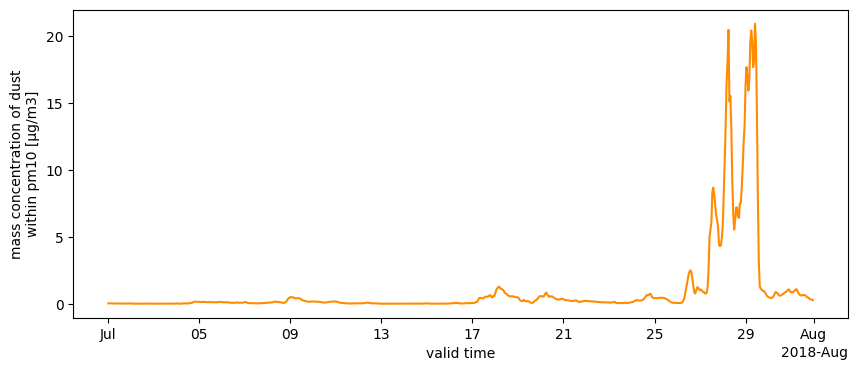

In [26]:
ds_regional['dust'].plot(figsize = (10, 4), color = "darkorange")

In [27]:
df = ds_regional.to_dataframe()
df = df.groupby(df.index.floor('D')).mean().reset_index()

In [29]:
df.head(10)

,time,dust
0,2018-07-01,0.021869
1,2018-07-02,0.010687
2,2018-07-03,0.011107
3,2018-07-04,0.061477
4,2018-07-05,0.126916
5,2018-07-06,0.091501
6,2018-07-07,0.055703
7,2018-07-08,0.148385
8,2018-07-09,0.314007
9,2018-07-10,0.138796
